<a href="https://colab.research.google.com/github/sonkd/HUST-MDS-Study/blob/main/projects/advanced-deep-learning/notebooks/ADL-ProjectCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🟢 Objectives

* **Objective 1 — Generative VQA with CLIP Backbone:** Xây dựng mô hình Visual Question Answering (VQA) theo hướng *generative* (decode câu trả lời token-by-token) bằng cách tận dụng visual và text embeddings từ CLIP ViT-B/32 pretrained làm encoder cố định.
* **Objective 2 — Selective CLIP Fine-tuning:** Áp dụng chiến lược unfreeze có chọn lọc (last N layers của ViT) với layer-wise learning rate để cải thiện khả năng adapt với visual domain đặc thù của VizWiz (ảnh chụp bởi người mù — mờ, xoay, thiếu sáng).
* **Objective 3 — Chuẩn hoá Evaluation:** Implement đúng **VQA Accuracy** (metric chính thức của VizWiz challenge) thay vì SQuAD F1/EM, kết hợp BLEU-1 để đánh giá đa chiều và so sánh kết quả giữa các cấu hình thí nghiệm.

**Model Optimization Strategy**: Transfer Learning (dùng pre-trained model CLIP ViT-B/32)

---

# Introduction

Dự án giải quyết bài toán **Visual Question Answering (VQA)** trên dataset **VizWiz** — bộ dữ liệu ảnh thực tế được chụp bởi người khiếm thị, khó hơn VQA v2 vì ảnh thường mờ/xoay, câu hỏi mơ hồ, và ~25% là "unanswerable".

**Kiến trúc tổng quan:**
```
Image   ──► VisionTransformer (CLIP ViT-B/32)  ──► image_feature    [N, D]
Question ──► Text Transformer  (CLIP)           ──► question_feature [N, D]
                                [image_feature ⊕ question_feature]
                                         ──► Decoder (LSTM) ──► Answer tokens
```

> 🔗 Reference: [CLIP — Radford et al., 2021](https://arxiv.org/abs/2103.00020) | [VizWiz challenge](https://vizwiz.org/tasks-and-datasets/vqa/)


# 🟢 Environment Setup

## 📦 Install

> **Môi trường được hỗ trợ:** Google Colab (T4 GPU) và VS Code với Python virtual environment.
>
> **Lưu ý VS Code:** `cv2_imshow` từ `google.colab.patches` không khả dụng local. Cell Import bên dưới tự động fallback sang `matplotlib` khi phát hiện không phải Colab.


In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
# lightning   : PyTorch Lightning — quản lý training loop, checkpoint, scheduler tự động
# torchmetrics: SQuAD EM/F1 và SacreBLEU metrics
# ftfy        : Unicode text normalization cho BPE tokenizer
# CLIP        : OpenAI CLIP ViT-B/32 pretrained model

!pip install opencv-python matplotlib lightning torchmetrics ftfy clip
!pip install -q --no-cache-dir git+https://github.com/openai/CLIP.git

print("✅ Installation complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 42.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6989 sha256=0b2666050bb3ee37251a041b80626c3ced3a06f64a7a401f6c53f2cedb13f787
  Stored in directory: /root/.cache/pip/wheels/6c/fd/54/9d4e15cf829b871199a7cd3597e869a514d1624a0a43076896
Successfully built clip
  Preparing metadata (setup.py) ... done
✅ Installation complete.


## 📥 Import

Toàn bộ dependencies tập trung tại đây. Có guard phát hiện Colab vs local để xử lý `cv2_imshow`.


In [2]:
import lightning as L

# ── Deep Learning Frameworks ──────────────────────────────────────────────────
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint

# ── Standard Library ─────────────────────────────────────────────────────────
import os, io, cv2, json, math, time, random, shutil, errno
import tarfile, logging, warnings, collections, gzip, html
from functools import lru_cache

# ── Scientific & Visualization ───────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── NLP ──────────────────────────────────────────────────────────────────────
import ftfy
import regex as re

# ── PyTorch Core ─────────────────────────────────────────────────────────────
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

# ── Metrics ──────────────────────────────────────────────────────────────────
from torchmetrics.text import SQuAD, SacreBLEUScore

# ── Dataset & Transform Utils ────────────────────────────────────────────────
from torchvision.datasets.utils import download_url, download_and_extract_archive
from torch.nn.utils.rnn import pad_sequence
from torchvision.transforms.v2 import Compose, Resize, CenterCrop, ToTensor, Normalize

try:
    from torchvision.transforms.v2 import InterpolationMode
    BICUBIC = InterpolationMode.BICUBIC
except ImportError:
    BICUBIC = Image.BICUBIC

# ── Environment Detection: Colab vs Local/VS Code ────────────────────────────
# cv2_imshow chỉ hoạt động trong Colab. Local environment (VS Code, Jupyter)
# sẽ dùng matplotlib fallback để tránh ImportError khi chạy offline.
try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
    print("🟢 Running in Google Colab")
except ImportError:
    def cv2_imshow(img):
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    IN_COLAB = False
    print("🟡 Running in local environment (VS Code / Jupyter) — cv2_imshow fallback active")

# ── CLIP Initialization ───────────────────────────────────────────────────────
# clip.load() trả về (model, preprocess_fn).
# Chỉ dùng model để copy pretrained weights sang kiến trúc custom.
# preprocess_fn bị bỏ qua vì ta dùng TRANSFORM tự định nghĩa.
import clip as clip_module
clip, _ = clip_module.load(
    "ViT-B/32",
    device="cuda" if torch.cuda.is_available() else "cpu",
)
print(f"✅ CLIP ViT-B/32 loaded | Device: {'cuda' if torch.cuda.is_available() else 'cpu (no GPU)'}")

warnings.filterwarnings("ignore")

# ── Plot Styling ──────────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams['axes.facecolor'] = 'lightgray'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'


🟢 Running in Google Colab


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 145MiB/s]


✅ CLIP ViT-B/32 loaded | Device: cuda


---
# ⚙️ Configuration

Tất cả hyperparameter tập trung ở đây. Khi chạy thí nghiệm, chỉ cần thay đổi trong section này rồi re-run từ "Load Dataset" trở xuống.


In [3]:
os.makedirs("experiment/training", exist_ok=True)
os.makedirs("experiment/dataset",  exist_ok=True)
os.makedirs("experiment/model",    exist_ok=True)
EXPERIMENT_DIR = "experiment/"
print("✅ Experiment directories ready.")


✅ Experiment directories ready.


In [4]:
# macOS local với spawn multiprocessing không tương thích với
# các class được định nghĩa trong notebook → buộc phải dùng 0.
# Colab dùng fork nên num_workers=2 hoạt động bình thường.
NUM_WORKERS = 0 if not IN_COLAB else 2

In [5]:
# Dùng val_loss làm tín hiệu checkpoint thay vì VQA Accuracy.
# Lý do: VQA Acc cần chạy autoregressive inference cho từng sample — quá chậm cho mỗi val epoch.
METRIC_TO_MONITOR = "val_loss"
METRIC_MODE       = "min"


In [6]:
# [FIX v2] Seed cố định để đảm bảo train/val split nhất quán giữa các lần chạy.
# v1 dùng np.random.randint() — thay đổi mỗi run → val set khác nhau → kết quả không so sánh được.
SEED = 42
print(f"Random seed: {SEED}")


Random seed: 42


In [7]:
# Temperature scaling: làm mềm softmax distribution → diverse outputs.
# Top-p (nucleus sampling): chỉ sample từ tập token có cumulative prob <= top_p.
# Kết hợp hai kỹ thuật này tránh greedy decoding (hay lặp từ) mà vẫn coherent.
TEMPERATURE = 0.1   # Nhỏ = conservative; lớn = sáng tạo hơn nhưng dễ noise
TOP_P       = 0.9


In [ ]:
IMAGE_SIZE   = 224 # kích thước chuẩn ViT-B/32 (patch 32x32, grid 7x7 = 49 patches).
MAX_SEQUENCE = 77  # giới hạn token của CLIP tokenizer.
HIDDEN_DIM   = 512 # output dim của CLIP ViT-B/32 projection layer.
MAX_EPOCH    = 36
BATCH_SIZE   = 96    # ⚠️  Giảm xuống 64 nếu UNFREEZE_LAST_N_LAYERS >= 3
NUM_LAYER    = 1     # Số LSTM layers trong Decoder
DROPOUT      = 0.42  # phù hợp vì decoder LSTM nhỏ, dễ overfit trên VizWiz.

In [9]:
# Khi giảm BATCH_SIZE (unfreeze CLIP, tránh OOM), dùng gradient accumulation
# để giữ effective batch size tương đương baseline.
# Ví dụ: BATCH_SIZE=64, GRAD_ACCUM_STEPS=3 → effective_batch = 64*3 = 192 ≈ 180 (baseline)
GRAD_ACCUM_STEPS = 2    # 🔬 Tăng lên 3 khi dùng BATCH_SIZE=64 (unfreeze experiments)


In [10]:
# ── Selective Unfreeze Config (Experiment Sprint 2) ──────────────────────────
# UNFREEZE_LAST_N_LAYERS=0: CLIP hoàn toàn frozen (Baseline).
# Tăng lên 2, 3, 4 để fine-tune last N resblocks của ViT image encoder.
# Text encoder LUÔN frozen — câu hỏi VizWiz là tiếng Anh thông thường,
# CLIP text encoder đã đủ tốt, không cần domain adaptation.
UNFREEZE_LAST_N_LAYERS = 2    # 🔬 Thay đổi: 0 (baseline), 2, 3, 4 để thí nghiệm
UNFREEZE_PARAM = True         # Legacy flag — không dùng trực tiếp trong v2


In [11]:
# LR_CLIP_FACTOR=0.1: CLIP unfrozen layers dùng LR nhỏ hơn decoder 10x.
# Nguyên lý: tránh catastrophic forgetting khi fine-tune pretrained layers.
LEARNING_RATE    = 4.1e-3
LR_CLIP_FACTOR   = 0.1       # CLIP unfrozen layers: LEARNING_RATE * LR_CLIP_FACTOR
REDUCE_LR_FACTOR = 0.37      # Gamma cho MultiStepLR scheduler


In [12]:
VOCAB_SIZE  = 49408
START_TOKEN = "<|startoftext|>"
END_TOKEN   = "<|endoftext|>"
PAD_TOKEN   = "!"


In [13]:
# LR drop schedule: phân bổ đều theo sqrt(MAX_EPOCH).
# MAX_EPOCH=36 → milestones ≈ [6, 12, 18, 24, 30] (step LR tại các epoch này).
# [FIX v2] Dùng round() thay vì int() để tránh float precision error.
# Lỗi cũ: int(36 * 5/6) = int(29.999...) = 29 thay vì 30.
MILESTONES = 1. / math.sqrt(MAX_EPOCH) * (
    np.array([m for m in range(1, int(math.sqrt(MAX_EPOCH)))])
)
_milestone_epochs = [round(MAX_EPOCH * ms) for ms in MILESTONES]
print(f"📅 LR drop epochs: {_milestone_epochs}")


📅 LR drop epochs: [6, 12, 18, 24, 30]


---
# 1. 🟢 Data Preparation & Processing

## 📥 Download Dataset

VizWiz gồm 3 split: train (~20k), val (~5k), test (~8k ảnh, không có annotations).
Annotations chứa: `image`, `question`, `answer_type`, và `answers` (list 10 annotators).

> ⏱️ Download + extract mất khoảng 10–15 phút trên Colab. Nếu đã có data, comment cell này lại.


Load từ file local đã tải

In [14]:
import zipfile

# Các file .zip đã tải về local — chỉ cần extract, không cần download
LOCAL_ZIPS = [
    ("experiment/dataset/train.zip",       "experiment/dataset"),
    ("experiment/dataset/val.zip",         "experiment/dataset"),
    ("experiment/dataset/test.zip",        "experiment/dataset"),
    ("experiment/dataset/Annotations.zip", "experiment/dataset"),
]

for zip_path, dest_dir in LOCAL_ZIPS:
    print(f"📦 Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest_dir)

print("✅ All extracted.")

📦 Extracting experiment/dataset/train.zip...


FileNotFoundError: [Errno 2] No such file or directory: 'experiment/dataset/train.zip'

Tải online khi dùng trên Colab

In [15]:
DATASET_URL = {
    "train"      : ("https://vizwiz.cs.colorado.edu/VizWiz_final/images/train.zip",       "train.zip"),
    "val"        : ("https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip",         "val.zip"),
    "test"       : ("https://vizwiz.cs.colorado.edu/VizWiz_final/images/test.zip",        "test.zip"),
    "annotation" : ("https://vizwiz.cs.colorado.edu/VizWiz_final/vqa_data/Annotations.zip","Annotations.zip"),
}

for dat in DATASET_URL.values():
    url, filename = dat
    download_and_extract_archive(url, "experiment/dataset", filename=filename)
    os.remove(os.path.join("experiment/dataset", filename))

download_url(
    "https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz",
    "experiment/model", "bpe_simple_vocab_16e6.txt.gz",
)
print("✅ Dataset and vocabulary downloaded.")


100%|██████████| 11.3G/11.3G [03:02<00:00, 61.8MB/s]
100%|██████████| 3.49G/3.49G [00:53<00:00, 65.7MB/s]
100%|██████████| 3.98G/3.98G [01:24<00:00, 46.9MB/s]
100%|██████████| 1.71M/1.71M [00:00<00:00, 11.7MB/s]
100%|██████████| 1.36M/1.36M [00:00<00:00, 46.8MB/s]

✅ Dataset and vocabulary downloaded.


## 🛠️ Utils

### Image Transform

CLIP được pretrain với ảnh normalize theo mean/std cụ thể — phải dùng đúng các giá trị này khi inference, không được thay đổi.

In [16]:
def _convert_image_to_rgb(image):
    # VizWiz có một số ảnh grayscale hoặc RGBA — cần convert về RGB trước khi transform
    return image.convert("RGB")

# Normalize values là mean/std cố định của tập ảnh CLIP được pretrain.
TRANSFORM = Compose([
    Resize(IMAGE_SIZE, interpolation=BICUBIC),
    CenterCrop(IMAGE_SIZE),
    _convert_image_to_rgb,
    ToTensor(),
    Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std= (0.26862954, 0.26130258, 0.27577711),
    ),
])


### BPE Tokenizer

Copy từ CLIP source để dùng độc lập. Tokenizer dùng Byte Pair Encoding với vocab 49408 tokens.

In [17]:
@lru_cache()
def default_bpe():
    return "experiment/model/bpe_simple_vocab_16e6.txt.gz"

@lru_cache()
def bytes_to_unicode():
    bs = (
        list(range(ord("!"), ord("~") + 1))
        + list(range(ord("\xa1"), ord("\xac") + 1))
        + list(range(ord("\xae"), ord("\xff") + 1))
    )
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    return dict(zip(bs, [chr(c) for c in cs]))

def get_pairs(word):
    pairs = set()
    prev = word[0]
    for char in word[1:]:
        pairs.add((prev, char))
        prev = char
    return pairs

def basic_clean(text):
    text = ftfy.fix_text(text)
    text = html.unescape(html.unescape(text))
    return text.strip()

def whitespace_clean(text):
    return re.sub(r'\s+', ' ', text).strip()


In [18]:
class SimpleTokenizer(object):
    def __init__(self, bpe_path: str = default_bpe()):
        self.byte_encoder = bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}
        merges = gzip.open(bpe_path).read().decode("utf-8").split("\n")
        merges = merges[1 : 49152 - 256 - 2 + 1]
        merges = [tuple(merge.split()) for merge in merges]
        vocab = list(bytes_to_unicode().values())
        vocab = vocab + [v + "</w>" for v in vocab]
        for merge in merges:
            vocab.append("".join(merge))
        vocab.extend(["<|startoftext|>", "<|endoftext|>"])
        self.encoder   = dict(zip(vocab, range(len(vocab))))
        self.decoder   = {v: k for k, v in self.encoder.items()}
        self.bpe_ranks = dict(zip(merges, range(len(merges))))
        self.cache = {"<|startoftext|>": "<|startoftext|>", "<|endoftext|>": "<|endoftext|>"}
        self.pat = re.compile(
            r"<\|startoftext\|>|<\|endoftext\|>|'s|'t|'re|'ve|'m|'ll|'d|[\p{L}]+|[\p{N}]|[^\s\p{L}\p{N}]+",
            re.IGNORECASE,
        )

    def bpe(self, token):
        if token in self.cache:
            return self.cache[token]
        word = tuple(token[:-1]) + (token[-1] + "</w>",)
        pairs = get_pairs(word)
        if not pairs:
            return token + "</w>"
        while True:
            bigram = min(pairs, key=lambda pair: self.bpe_ranks.get(pair, float("inf")))
            if bigram not in self.bpe_ranks:
                break
            first, second = bigram
            new_word, i = [], 0
            while i < len(word):
                try:
                    j = word.index(first, i)
                    new_word.extend(word[i:j])
                    i = j
                except Exception:
                    new_word.extend(word[i:])
                    break
                if word[i] == first and i < len(word) - 1 and word[i + 1] == second:
                    new_word.append(first + second)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            word = tuple(new_word)
            if len(word) == 1:
                break
            pairs = get_pairs(word)
        word = " ".join(word)
        self.cache[token] = word
        return word

    def encode(self, text):
        bpe_tokens = []
        text = whitespace_clean(basic_clean(text)).lower()
        for token in re.findall(self.pat, text):
            token = "".join(self.byte_encoder[b] for b in token.encode("utf-8"))
            bpe_tokens.extend(self.encoder[bpe_token] for bpe_token in self.bpe(token).split(" "))
        return bpe_tokens

    def decode(self, tokens):
        text = "".join([self.decoder[token] for token in tokens if token in self.decoder])
        return bytearray([self.byte_decoder[c] for c in text]).decode("utf-8", errors="replace").replace("</w>", " ")

SimpleTokenizer = SimpleTokenizer()
print("✅ Tokenizer initialized.")


✅ Tokenizer initialized.


In [19]:
def tokenize(texts, context_length=MAX_SEQUENCE, truncate=True):
    """
    Tokenize text(s) thành tensor IDs.
    Output shape: [len(texts), context_length]
    Layout: [SOT, token_1, ..., token_n, EOT, 0, 0, ...]
    """
    if isinstance(texts, str):
        texts = [texts]
    sot = SimpleTokenizer.encoder[START_TOKEN]
    eot = SimpleTokenizer.encoder[END_TOKEN]
    all_tokens = [[sot] + SimpleTokenizer.encode(t) + [eot] for t in texts]
    result = torch.zeros(len(all_tokens), context_length, dtype=torch.long)
    for i, tokens in enumerate(all_tokens):
        if len(tokens) > context_length:
            tokens = tokens[:context_length]
            tokens[-1] = eot
        result[i, :len(tokens)] = torch.tensor(tokens)
    return result


### VQA Dataset

`VizWizDataset` xử lý 3 loại `answer_type`: `unanswerable`, `yes/no`, `other`.

**Thay đổi so với v1:**
- **Train/Val split 90/10** (tăng từ 99/1) — val set đủ lớn cho checkpoint selection đáng tin cậy.
- **Majority vote cho yes/no** thay vì chỉ dùng `answers[0]`.
- **Lưu `all_answers`** (list 10 annotators) để tính VQA Accuracy chuẩn tại inference time.


In [20]:
from torchvision.transforms import v2

TRANSFORM_TRAIN = v2.Compose([
    v2.Resize(IMAGE_SIZE + 32, interpolation=BICUBIC),
    v2.RandomCrop(IMAGE_SIZE),           # thay CenterCrop
    v2.RandomHorizontalFlip(p=0.3),
    v2.ColorJitter(
        brightness=0.3,                  # VizWiz hay bị thiếu sáng
        contrast=0.3,
        saturation=0.2,
    ),
    v2.RandomRotation(degrees=15),       # VizWiz hay bị xoay
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),  # mô phỏng ảnh mờ
    _convert_image_to_rgb,
    v2.ToTensor(),
    v2.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std= (0.26862954, 0.26130258, 0.27577711),
    ),
])

# Val/Test giữ nguyên TRANSFORM gốc — không augment
TRANSFORM_VAL = TRANSFORM   # giữ nguyên CenterCrop + Normalize

In [21]:
class VizWizDataset(data.Dataset):
    def __init__(self, split, transform=None):
        # Tự chọn transform theo split nếu không truyền vào
        if transform is None:
            transform = TRANSFORM_TRAIN if split == "train" else TRANSFORM_VAL
        self.transform = transform

        assert split in ["train", "val", "test", "inference"]

        # Mapping split → annotation file và image directory.
        # "test" dùng val.json vì VizWiz official test set không có annotations.
        # "inference" dùng test.json cho demo (unlabelled).
        if split in ["train", "val"]:
            ann_path = "experiment/dataset/train.json"
            self.root_dir = "experiment/dataset/train"
        elif split == "test":
            ann_path = "experiment/dataset/val.json"
            self.root_dir = "experiment/dataset/val"
        else:  # inference
            ann_path = "experiment/dataset/test.json"
            self.root_dir = "experiment/dataset/test"

        with open(ann_path) as f:
            json_data = json.load(f)

        self.dataset = []
        for jdat in json_data:
            try:
                img, q = jdat["image"], jdat["question"].lower()

                if jdat["answer_type"] == "unanswerable":
                    self.dataset.append((img, q, "unanswerable", ["unanswerable"] * 10))
                    continue

                if jdat["answer_type"] == "yes/no":
                    # [FIX v2] Majority vote — v1 chỉ dùng answers[0]
                    yes_count = sum(1 for a in jdat["answers"] if "yes" in a["answer"].lower())
                    sentiment = "yes" if yes_count > len(jdat["answers"]) / 2 else "no"
                    all_ans   = [a["answer"].lower() for a in jdat["answers"]]
                    self.dataset.append((img, q, sentiment, all_ans))
                    continue

                # Open-ended: majority vote
                count = {}
                for a in jdat["answers"]:
                    k = a["answer"].lower()
                    count[k] = count.get(k, 0) + 1
                best = max(count, key=count.get)
                all_ans = [a["answer"].lower() for a in jdat["answers"]]
                self.dataset.append((img, q, best, all_ans))

            except Exception:
                # Inference items không có answer field
                self.dataset.append((jdat["image"], jdat["question"].lower(), None, []))

        # [FIX v2] 90/10 split thay vì 99/1 — val set đủ lớn cho checkpoint selection
        if split == "train":
            random.seed(SEED)
            random.shuffle(self.dataset)
            self.dataset = self.dataset[:int(0.90 * len(self.dataset))]
        elif split == "val":
            random.seed(SEED)
            random.shuffle(self.dataset)
            self.dataset = self.dataset[int(0.90 * len(self.dataset)):]

        self.split     = split
        self.transform = transform
        print(f"  [{split}] {len(self.dataset):,} samples loaded.")

    def __len__(self): return len(self.dataset)

    def __getitem__(self, index):
        assert self.split != "inference"
        img_path, question, answer, _ = self.dataset[index]
        image = Image.open(os.path.join(self.root_dir, img_path))
        if self.transform: image = self.transform(image)
        return image, tokenize(question)[0].long(), tokenize(answer)[0].long()

    def get_all_answers(self, index):
        """Trả về list đầy đủ 10 annotator answers — dùng để tính VQA Accuracy."""
        return self.dataset[index][3]

    def get_raw_question(self, index):
        assert self.split == "inference"
        return self.dataset[index][1]

    def get_raw_image(self, index):
        assert self.split == "inference"
        return Image.open(os.path.join(self.root_dir, self.dataset[index][0]))

    def get_inference_data(self, index):
        assert self.split == "inference"
        image    = Image.open(os.path.join(self.root_dir, self.dataset[index][0]))
        if self.transform: image = self.transform(image)
        question = tokenize(self.dataset[index][1])[0]
        return image, question.long()


### Collate Function

Xử lý padding cho answer tokens trong batch. Trick: thêm dummy tensor `[MAX_SEQUENCE+1]` để `pad_sequence` luôn tạo output có chiều dài ít nhất `MAX_SEQUENCE+1`, đảm bảo `answer[:, :-1]` (decoder input) và `answer[:, 1:]` (shifted labels) luôn có shape nhất quán `[B, 77]`.


In [22]:
class CollateFunction(object):
    def __init__(self, pad_idx=0):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        images    = torch.cat([item[0].unsqueeze(0) for item in batch], dim=0)
        questions = torch.cat([item[1].unsqueeze(0) for item in batch], dim=0)
        # Dummy tensor đảm bảo max_len >= MAX_SEQUENCE+1 sau padding
        answers = [item[2] for item in batch] + [torch.randn(MAX_SEQUENCE + 1)]
        answers = pad_sequence(answers, batch_first=True, padding_value=self.pad_idx)[:-1, ...]
        return images, questions.long(), answers.long()

# CollateFunction = CollateFunction()
collate_function = CollateFunction()


## 📊 Load Dataset & EDA

In [23]:
print("Loading datasets...")
TrainDataset = VizWizDataset("train")
ValDataset   = VizWizDataset("val")
TestDataset  = VizWizDataset("test")


Loading datasets...
  [train] 18,470 samples loaded.
  [val] 2,053 samples loaded.
  [test] 4,319 samples loaded.


Answer Type             Count  Percent
----------------------------------------
other                  13,733    66.9%
unanswerable            5,532    27.0%
yes/no                    957     4.7%
number                    301     1.5%


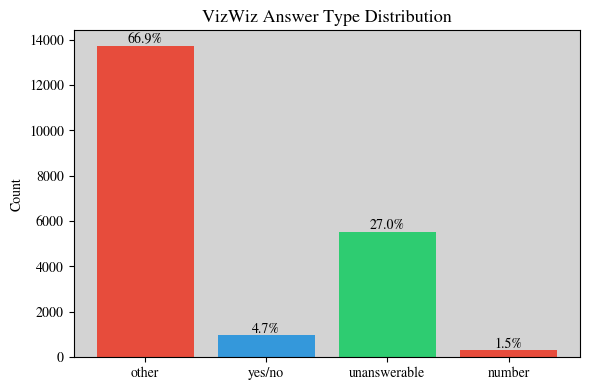

In [24]:
# ── EDA: Answer Type Distribution ────────────────────────────────────────────
# Hiểu phân phối answer_type giúp đánh giá model behavior:
# - "unanswerable" ~25%: model cần học từ chối thay vì hallucinate
# - "yes/no"       ~20%: binary, dễ predict nhưng dễ bị bias về "yes"
# - "other"        ~55%: open-ended — phần khó và quan trọng nhất

with open("experiment/dataset/train.json") as f:
    _train_json = json.load(f)

type_counts = {}
for jdat in _train_json:
    t = jdat.get("answer_type", "unknown")
    type_counts[t] = type_counts.get(t, 0) + 1
total = sum(type_counts.values())

print(f"{'Answer Type':<20} {'Count':>8} {'Percent':>8}")
print("-" * 40)
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"{k:<20} {v:>8,} {v/total*100:>7.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#E74C3C", "#3498DB", "#2ECC71"]
bars   = ax.bar(type_counts.keys(), type_counts.values(), color=colors[:len(type_counts)])
ax.set_title("VizWiz Answer Type Distribution", fontsize=13)
ax.set_ylabel("Count")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{bar.get_height()/total*100:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


---
# 2. 🟢 Modeling

## Utils


In [25]:
class AvgMeter(object):
    """Accumulate loss values trong một epoch và trả về mean."""
    def __init__(self): self.reset()
    def reset(self):    self.scores = []
    def update(self, val): self.scores.append(val)
    def show(self):     return torch.mean(torch.stack(self.scores))


## VQA Accuracy — Official Metric

`vqa_accuracy` là metric chính thức của VizWiz/VQA challenge.

**Công thức:** `score = min(count_matching_annotators / 3, 1.0)`

**Tại sao không dùng exact match thông thường?** 10 annotators có thể cho nhiều câu trả lời hợp lệ ("white", "cream", "off-white" cho cùng một màu). Nếu model predict đúng 3 trong 10 annotators, đó đã là điểm tối đa (1.0). SQuAD EM/F1 không capture được semantics này.


In [32]:
def vqa_accuracy(pred: str, all_answers: list) -> float:
    """
    VizWiz/VQA official accuracy.
    score = min(number_of_matching_annotators / 3, 1.0)

    Args:
        pred        : prediction string từ model
        all_answers : list các câu trả lời từ tối đa 10 annotators
    Returns:
        float trong [0, 1]
    """
    pred  = pred.strip().lower()
    count = sum(1 for a in all_answers if a.strip().lower() == pred)
    return min(count / 3, 1.0)


## Module Architecture

Building blocks:
- `build_attention_mask` — causal mask cho text Transformer (upper-triangular -inf)
- `QuickGELU` — fast GELU approximation dùng trong CLIP MLP blocks
- `ResidualAttentionBlock` — block cơ bản (MultiheadAttn + MLP + pre-LayerNorm)
- `Transformer` — stack các ResidualAttentionBlock
- `VisionTransformer` — ViT-B/32 image encoder (copy kiến trúc từ CLIP)
- `Decoder` — LSTM decoder generate answer tokens


In [33]:
def build_attention_mask():
    """
    Causal mask: upper triangle = -inf, lower + diagonal = 0.
    Đảm bảo position i chỉ attend đến positions 0..i (không nhìn vào token tương lai).
    """
    mask = torch.empty(MAX_SEQUENCE, MAX_SEQUENCE)
    mask.fill_(float("-inf"))
    mask.triu_(1)
    return mask

class QuickGELU(nn.Module):
    """Fast approximation: x * sigmoid(1.702x). Được dùng trong MLP blocks của CLIP."""
    def forward(self, x: torch.Tensor):
        return x * torch.sigmoid(1.702 * x)

class ResidualAttentionBlock(nn.Module):
    def __init__(self, d_model: int, n_head: int, attn_mask: torch.Tensor = None):
        super().__init__()
        self.attn      = nn.MultiheadAttention(d_model, n_head)
        self.ln_1      = nn.LayerNorm(d_model)
        self.mlp       = nn.Sequential(collections.OrderedDict([
            ("c_fc",   nn.Linear(d_model, d_model * 4)),
            ("gelu",   QuickGELU()),
            ("c_proj", nn.Linear(d_model * 4, d_model)),
        ]))
        self.ln_2      = nn.LayerNorm(d_model)
        self.attn_mask = attn_mask

    def attention(self, x: torch.Tensor):
        mask = self.attn_mask.to(dtype=x.dtype, device=x.device) if self.attn_mask is not None else None
        return self.attn(x, x, x, need_weights=False, attn_mask=mask)[0]

    def forward(self, x: torch.Tensor):
        x = x + self.attention(self.ln_1(x))   # Pre-norm attention
        x = x + self.mlp(self.ln_2(x))          # Pre-norm MLP
        return x

class Transformer(nn.Module):
    def __init__(self, width: int, layers: int, heads: int, attn_mask: torch.Tensor = None):
        super().__init__()
        self.width    = width
        self.layers   = layers
        self.resblocks = nn.Sequential(*[ResidualAttentionBlock(width, heads, attn_mask) for _ in range(layers)])
    def forward(self, x: torch.Tensor):
        return self.resblocks(x)


In [ ]:
class VisionTransformer(nn.Module):
    """
    ViT-B/32: chia ảnh 224x224 thành patches 32x32 (grid 7x7=49 patches).
    Thêm class token → 50 tokens vào sequence.
    Output: class token sau projection → [N, HIDDEN_DIM=512].
    """
    def __init__(
        self,
        input_resolution: int = IMAGE_SIZE,
        patch_size: int = 32,
        width: int = 768,
        layers: int = 12,
        heads: int = 12,
        output_dim: int = HIDDEN_DIM,
    ):
        super().__init__()
        self.input_resolution = input_resolution
        self.output_dim       = output_dim
        self.conv1            = nn.Conv2d(3, width, kernel_size=patch_size, stride=patch_size, bias=False)
        scale = width ** -0.5
        self.class_embedding      = nn.Parameter(scale * torch.randn(width))
        self.positional_embedding = nn.Parameter(scale * torch.randn((input_resolution // patch_size) ** 2 + 1, width))
        self.ln_pre      = nn.LayerNorm(width)
        self.transformer = Transformer(width, layers, heads)
        self.ln_post     = nn.LayerNorm(width)
        self.proj        = nn.Parameter(scale * torch.randn(width, output_dim))

    def forward(self, x: torch.Tensor):
        x = self.conv1(x)                                    # (B, width, H/p, W/p)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)    # (B, width, N_patches) -> (B, N_patches, width)
        x = torch.cat([
            self.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device),
            x,
        ], dim=1)                                            # (B, N_patches+1, width)
        x = x + self.positional_embedding.to(x.dtype)
        x = self.ln_pre(x)
        # Transformer yêu cầu đầu vào dạng (seq_len, batch, dim) → chuyển đổi
        x = x.permute(1, 0, 2)                               # (N_patches+1, B, width)
        x = self.transformer(x)                              # cùng kích thước
        x = x.permute(1, 0, 2)                               # (B, N_patches+1, width)
        # Lấy class token (vị trí 0) và LayerNorm
        x = self.ln_post(x[:, 0, :])                         # (B, width)
        if self.proj is not None: x = x @ self.proj          # (B, output_dim)
        return x


In [35]:
class Decoder(nn.Module):
    """
    LSTM-based generative decoder.

    Forward flow:
      1. Embed answer tokens: [N, seq_len] → [N, seq_len, D]
      2. Multiplicative gating với fused context:
         x = token_emb * in_projection(cat[q_feat, img_feat])
         (gating đơn giản — không phải cross-attention)
      3. LSTM sequence modeling
      4. Linear projection → vocabulary logits [N, seq_len, VOCAB_SIZE]

    in_projection nhận [N, 1, 2D] và broadcast với [N, seq_len, D].
    """
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, HIDDEN_DIM)
        # Khởi tạo từ CLIP embeddings để tận dụng pretrained language representation
        self.token_embedding.weight.data = clip.token_embedding.weight.data.to(torch.float32).clone()
        self.token_embedding.weight.requires_grad = True  # Decoder embedding luôn trainable
        self.lstm           = nn.LSTM(HIDDEN_DIM, HIDDEN_DIM, NUM_LAYER, batch_first=True)
        self.in_projection  = nn.Linear(2 * HIDDEN_DIM, HIDDEN_DIM)
        self.out_projection = nn.Linear(HIDDEN_DIM, VOCAB_SIZE)

    def forward(self, x, y, z):
        """x: answer IDs [N,S], y: question feat [N,1,D], z: image feat [N,1,D]"""
        x = self.token_embedding(x)
        x = x * self.in_projection(torch.cat([y, z], dim=-1))  # broadcast gate
        x = F.dropout(x, DROPOUT, self.training)
        x, _ = self.lstm(x)
        x = F.dropout(x, DROPOUT, self.training)
        return self.out_projection(x)


## Wrapper — VisualQuestionAnswering (Lightning Module)

Core module kết hợp tất cả thành phần.

**Selective Unfreeze:** Thay vì `UNFREEZE_PARAM = True/False` cho toàn bộ CLIP, v2 unfreeze có chọn lọc `UNFREEZE_LAST_N_LAYERS` cuối của ViT. Text encoder luôn frozen.

**Layer-wise LR:** CLIP unfrozen layers dùng `LEARNING_RATE * LR_CLIP_FACTOR` (nhỏ hơn 10x) để tránh Catastrophic Forgetting.

**[FIX] Manual optimization:** `self.automatic_optimization = False` — gradient clipping được kiểm soát thủ công. Scheduler trả về từ `configure_optimizers` với `interval='epoch'`, Lightning auto-step — không gọi thêm `sch.step()` nữa.


In [ ]:
class VisualQuestionAnswering(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.batch_size = BATCH_SIZE
        self.max_epoch  = MAX_EPOCH
        self.lr         = LEARNING_RATE
        self.lr_now     = self.lr

        # ── Image Encoder ─────────────────────────────────────────────────────
        self.image_extractor = VisionTransformer()
        self._load_clip_visual_weights()
        self._apply_selective_unfreeze()

        # ── Text Encoder (always frozen) ──────────────────────────────────────
        self.token_embedding      = nn.Embedding(VOCAB_SIZE, HIDDEN_DIM)
        self.positional_embedding = nn.Parameter(torch.randn(MAX_SEQUENCE, HIDDEN_DIM))
        self.transformer          = Transformer(HIDDEN_DIM, 12, 8, build_attention_mask())
        self.ln_final             = nn.LayerNorm(HIDDEN_DIM)
        self.text_projection      = nn.Parameter(torch.randn(HIDDEN_DIM, HIDDEN_DIM))
        self._load_clip_text_weights()

        # ── Decoder (trainable) ───────────────────────────────────────────────
        self.decoder = Decoder()

        # ── Training state ────────────────────────────────────────────────────
        self.automatic_optimization = False
        self.train_loss = []
        self.val_loss   = []
        self.train_loss_recorder = AvgMeter()
        self.val_loss_recorder   = AvgMeter()
        self.test_squad = SQuAD()
        self.test_bleu  = SacreBLEUScore(n_gram=1)
        self.sanity_check_counter = 1

    # ── Weight Loading Helpers ─────────────────────────────────────────────────

    def _copy_block_weights(self, dst_blocks, src_blocks, freeze=True):
        """Copy transformer resblock weights từ source sang destination."""
        for l, rb in enumerate(dst_blocks):
            src = src_blocks[l]
            for attr in ["attn.out_proj.weight", "attn.out_proj.bias",
                         "attn.in_proj_weight",  "attn.in_proj_bias",
                         "ln_1.weight", "ln_1.bias", "ln_2.weight", "ln_2.bias"]:
                parts = attr.split(".")
                d, s = rb, src
                for p in parts[:-1]: d, s = getattr(d, p), getattr(s, p)
                t = getattr(s, parts[-1]).data.to(torch.float32).clone()
                getattr(d, parts[-1]).data = t
                if freeze: getattr(d, parts[-1]).requires_grad = False
            for mi in [0, 2]:
                rb.mlp[mi].weight.data = src.mlp[mi].weight.data.to(torch.float32).clone()
                rb.mlp[mi].bias.data   = src.mlp[mi].bias.data.to(torch.float32).clone()
                if freeze:
                    rb.mlp[mi].weight.requires_grad = False
                    rb.mlp[mi].bias.requires_grad   = False
            try: rb.attn_mask = src.attn_mask.to(torch.float32).clone()
            except Exception: pass

    def _load_clip_visual_weights(self):
        ve, cv = self.image_extractor, clip.visual
        ve.conv1.weight.data            = cv.conv1.weight.data.to(torch.float32).clone()
        ve.class_embedding.data         = cv.class_embedding.data.to(torch.float32).clone()
        ve.positional_embedding.data    = cv.positional_embedding.data.to(torch.float32).clone()
        ve.proj.data                    = cv.proj.to(torch.float32).clone()
        ve.ln_pre.weight.data           = cv.ln_pre.weight.data.to(torch.float32).clone()
        ve.ln_pre.bias.data             = cv.ln_pre.bias.data.to(torch.float32).clone()
        ve.ln_post.weight.data          = cv.ln_post.weight.data.to(torch.float32).clone()
        ve.ln_post.bias.data            = cv.ln_post.bias.data.to(torch.float32).clone()
        self._copy_block_weights(ve.transformer.resblocks, cv.transformer.resblocks, freeze=True)
        for p in ve.parameters(): p.requires_grad = False  # Freeze all first

    def _apply_selective_unfreeze(self):
        """
        Unfreeze last UNFREEZE_LAST_N_LAYERS của ViT image encoder.
        n=0: hoàn toàn frozen (baseline).
        n=2,3,4: fine-tune last layers với layer-wise LR (10x nhỏ hơn decoder).
        """
        if UNFREEZE_LAST_N_LAYERS == 0:
            print("🔒 ViT fully frozen — Baseline config")
            return
        n_total = len(self.image_extractor.transformer.resblocks)
        for l, rb in enumerate(self.image_extractor.transformer.resblocks):
            if l >= n_total - UNFREEZE_LAST_N_LAYERS:
                for p in rb.parameters(): p.requires_grad = True
        for p in [self.image_extractor.ln_post.weight, self.image_extractor.ln_post.bias,
                  self.image_extractor.proj]:
            p.requires_grad = True
        unfrz = sum(p.numel() for p in self.image_extractor.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.image_extractor.parameters())
        print(f"🔓 Unfrozen last {UNFREEZE_LAST_N_LAYERS} ViT layers "
              f"({unfrz:,}/{total:,} params, {unfrz/total*100:.1f}%)")

    def _load_clip_text_weights(self):
        self.token_embedding.weight.data   = clip.token_embedding.weight.data.to(torch.float32).clone()
        self.positional_embedding.data     = clip.positional_embedding.data.to(torch.float32).clone()
        self.ln_final.weight.data          = clip.ln_final.weight.data.to(torch.float32).clone()
        self.ln_final.bias.data            = clip.ln_final.bias.data.to(torch.float32).clone()
        self.text_projection.data          = clip.text_projection.data.to(torch.float32).clone()
        self._copy_block_weights(self.transformer.resblocks, clip.transformer.resblocks, freeze=True)
        for p in [self.token_embedding.parameters(), [self.positional_embedding],
                  [self.text_projection], self.transformer.parameters(), self.ln_final.parameters()]:
            for param in p:
                if hasattr(param, 'requires_grad'): param.requires_grad = False

    # ── Encoding ──────────────────────────────────────────────────────────────

    def encode_image(self, image):
        x = self.image_extractor.conv1(image.type(self.image_extractor.conv1.weight.dtype))
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
        x = torch.cat([
            self.image_extractor.class_embedding.to(x.dtype)
            + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device),
            x,
        ], dim=1)
        x = x + self.image_extractor.positional_embedding.to(x.dtype)
        x = self.image_extractor.ln_pre(x)
        x = x.permute(1, 0, 2)                         # (seq_len, batch, width)
        x = self.image_extractor.transformer(x)
        x = x.permute(1, 0, 2)                         # (batch, seq_len, width)
        x = self.image_extractor.ln_post(x[:, 0, :])
        return x @ self.image_extractor.proj

    def encode_text(self, text):
        x = self.token_embedding(text)
        x = x + self.positional_embedding.type(x.dtype)
        x = x.permute(1, 0, 2)                         # (seq_len, B, embed_dim)
        x = self.transformer(x.type(x.dtype))          
        x = x.permute(1, 0, 2)                         # (B, seq_len, embed_dim)
        x = self.ln_final(x)
        return x[torch.arange(x.shape[0]), text.argmax(dim=-1)] @ self.text_projection.type(x.dtype)

    def encoder(self, image, question):
        img_f = self.encode_image(image)
        q_f   = self.encode_text(question)
        img_f = img_f / img_f.norm(dim=1, keepdim=True)
        q_f   = q_f   / q_f.norm(dim=1, keepdim=True)
        return img_f.unsqueeze(1), q_f.unsqueeze(1)

    def forward(self, image, question, answer):
        img_f, q_f = self.encoder(image, question)
        return self.decoder(answer, q_f, img_f)

    # ── Autoregressive Generation ─────────────────────────────────────────────

    def respond(self, image, question, temperature=TEMPERATURE, top_p=TOP_P):
        """
        Top-p (nucleus) sampling cho inference.
        Token generate lần lượt, điều kiện trên image + question features.
        """
        assert image.shape[0] == 1
        img_f, q_f = self.encoder(image, question)
        token = SimpleTokenizer.encode(START_TOKEN) + [0] * MAX_SEQUENCE
        for index in range(MAX_SEQUENCE):
            ans_so_far = torch.LongTensor(token[:-1]).unsqueeze(0).to(self.device)
            pred = self.decoder(ans_so_far, q_f, img_f)
            if temperature > 0:
                pred = (pred / temperature).softmax(-1)[0, index:index+1]
                psort, pidx = torch.sort(pred, dim=-1, descending=True)
                psum = torch.cumsum(psort, dim=-1)
                psort[psum - psort > top_p] = 0.
                psort.div_(psort.sum(dim=-1, keepdim=True))
                next_tok = torch.gather(pidx, -1, torch.multinomial(psort, num_samples=1)).transpose(0, 1)
            else:
                next_tok = pred.softmax(-1).argmax(2)[:, index]
            token[index + 1] = next_tok.item()
            if next_tok.item() == SimpleTokenizer.encode(END_TOKEN)[0]:
                break
        return self.postprocess_text(SimpleTokenizer.decode(token))

    def postprocess_text(self, text):
        for t in [START_TOKEN, END_TOKEN, PAD_TOKEN]:
            text = text.replace(t, "")
        return text.strip()

    # ── Training Steps ────────────────────────────────────────────────────────

    def training_step(self, batch, batch_nb):
        image, question, answer = batch
        pred   = self(image, question, answer[:, :-1]).view(-1, VOCAB_SIZE)
        target = answer[:, 1:].reshape(-1)
        # loss   = F.cross_entropy(pred, target, ignore_index=0) / GRAD_ACCUM_STEPS
        loss = F.cross_entropy(pred, target,ignore_index=0,label_smoothing=0.1) / GRAD_ACCUM_STEPS  # Label smoothing phạt trực tiếp token overconfident
        opt = self.optimizers()
        # Chỉ zero_grad ở bước đầu tiên của mỗi accumulation cycle.
        # Nếu zero_grad mỗi batch, gradient của các batch trước bị xóa —
        # accumulation không có tác dụng gì.
        if batch_nb % GRAD_ACCUM_STEPS == 0:
            opt.zero_grad()
        self.manual_backward(loss)

        # Chỉ update optimizer sau khi đã accumulate đủ số steps.
        # is_last_batch để đảm bảo batch cuối epoch cũng được update
        # dù số batch không chia hết cho GRAD_ACCUM_STEPS.
        is_last_batch = (batch_nb + 1) == self.trainer.num_training_batches
        if (batch_nb + 1) % GRAD_ACCUM_STEPS == 0 or is_last_batch:
            torch.nn.utils.clip_grad_value_(
                self.parameters(),
                math.sqrt(math.pi * math.e),
            )
            opt.step()

        self.log("train_loss", loss, prog_bar=True)
        self.train_loss_recorder.update(loss.data)

    def on_train_epoch_end(self):
        # [FIX v2] Không gọi sch.step() thủ công.
        # Lightning tự gọi qua configure_optimizers(interval='epoch').
        # Gọi thêm = double stepping = LR decay 2x nhanh (bug v1).
        self.train_loss.append(self.train_loss_recorder.show().data.cpu().numpy())
        self.train_loss_recorder = AvgMeter()

    def validation_step(self, batch, batch_nb):
        image, question, answer = batch
        pred   = self(image, question, answer[:, :-1]).view(-1, VOCAB_SIZE)
        target = answer[:, 1:].reshape(-1)
        # loss   = F.cross_entropy(pred, target, ignore_index=0)
        loss = F.cross_entropy(pred, target,ignore_index=0,label_smoothing=0.1) # Label smoothing phạt trực tiếp token overconfident
        if self.sanity_check_counter == 0:
            self.log("val_loss", loss, prog_bar=True)
            self.val_loss_recorder.update(loss.data)

    def on_validation_epoch_end(self):
        if self.sanity_check_counter == 0:
            loss    = self.val_loss_recorder.show().data.cpu().numpy()
            lr_now_ = self.optimizers().param_groups[0]["lr"]
            if self.lr_now != lr_now_:
                self.lr_now = lr_now_
                print(f"📉 LR changed → {lr_now_:.2e} at epoch {self.current_epoch}")
            self.val_loss.append(loss)
            self.val_loss_recorder = AvgMeter()
        else:
            self.sanity_check_counter -= 1

    def test_step(self, batch, batch_nb):
        """
        Evaluation với 3 metrics:
        1. VQA Accuracy (primary) — chuẩn VizWiz challenge
        2. SQuAD F1/EM (legacy)  — giữ để so sánh với baseline cũ
        3. BLEU-1                — n-gram overlap đơn giản
        """
        image, question, answer = batch
        N = image.shape[0]
        vqa_scores, squad_pred, squad_tgt, bleu_scores = [], [], [], []

        for i in range(N):
            pred   = self.respond(image[i].unsqueeze(0), question[i].unsqueeze(0))
            target = self.postprocess_text(SimpleTokenizer.decode(answer[i].cpu().tolist()))
            # VQA Accuracy: cần all_answers (10 annotators)
            all_ans = TestDataset.get_all_answers(batch_nb * N + i)
            vqa_scores.append(vqa_accuracy(pred, all_ans) if all_ans else 0.0)
            squad_pred.append({"prediction_text": pred, "id": i})
            squad_tgt.append({"answers": {"answer_start": [i], "text": [target]}, "id": i})
            bleu_scores.append(self.test_bleu([pred], [[target]]).cpu().item())

        squad = self.test_squad(squad_pred, squad_tgt)
        self.log("test_vqa_accuracy", float(np.mean(vqa_scores)), prog_bar=True)
        self.log("test_exact_match",  squad["exact_match"],        prog_bar=True)
        self.log("test_f1",           squad["f1"],                 prog_bar=True)
        self.log("bleu_1gram",        float(np.mean(bleu_scores)), prog_bar=True)

    def on_train_end(self):
        loss_file = f"experiment/training/{MODEL_NAME}_loss_plot.png"
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(self.train_loss, color="#E74C3C", linewidth=1.5, label="Train")
        ax.plot(self.val_loss,   color="#3498DB", linewidth=1.5, label="Validation")
        for ep in _milestone_epochs:
            ax.axvline(x=ep, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
        ax.text(0.02, 0.95, "Dashed = LR drop milestones", transform=ax.transAxes,
                fontsize=8, color="gray", va="top")
        ax.set_title(f"Loss Curves — {MODEL_NAME} | unfreeze={UNFREEZE_LAST_N_LAYERS} layers", fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-Entropy Loss")
        ax.legend()
        ax.grid(alpha=0.4)
        plt.tight_layout()
        plt.savefig(loss_file, dpi=120)
        plt.show()
        cv2_imshow(cv2.imread(loss_file))

    # ── DataLoaders ────────────────────────────────────────────────────────────

    def train_dataloader(self):
        return data.DataLoader(TrainDataset, batch_size=self.batch_size, shuffle=True,
                               collate_fn=collate_function, num_workers=NUM_WORKERS, persistent_workers=False)
    def val_dataloader(self):
        return data.DataLoader(ValDataset, batch_size=self.batch_size, shuffle=False,
                               collate_fn=collate_function, num_workers=NUM_WORKERS, persistent_workers=False)
    def test_dataloader(self):
        return data.DataLoader(TestDataset, batch_size=self.batch_size, shuffle=False,
                               collate_fn=collate_function, num_workers=NUM_WORKERS, persistent_workers=False)

    # persistent_workers=True chỉ có nghĩa khi num_workers > 0

    # ── Optimizer & Scheduler ─────────────────────────────────────────────────

    def configure_optimizers(self):
        """
        Layer-wise LR: CLIP unfrozen layers dùng LR nhỏ hơn decoder 10x.
        [FIX v2] Scheduler có interval='epoch' — Lightning auto-steps, không gọi thủ công.
        """
        if UNFREEZE_LAST_N_LAYERS > 0:
            clip_params    = [p for n, p in self.named_parameters() if "image_extractor" in n and p.requires_grad]
            decoder_params = [p for n, p in self.named_parameters() if "image_extractor" not in n and p.requires_grad]
            param_groups = [
                {"params": clip_params,    "lr": self.lr * LR_CLIP_FACTOR, "name": "clip_visual"},
                {"params": decoder_params, "lr": self.lr,                  "name": "decoder"},
            ]
            print(f"⚙️  clip_visual: {len(clip_params)} tensors @ lr={self.lr*LR_CLIP_FACTOR:.2e} | "
                  f"decoder: {len(decoder_params)} tensors @ lr={self.lr:.2e}")
            optimizer = optim.AdamW(param_groups, betas=(0.9, 0.98), eps=1e-9)
        else:
            optimizer = optim.AdamW(self.parameters(), self.lr, betas=(0.9, 0.98), eps=1e-9)

        return [optimizer], [{
            "scheduler": optim.lr_scheduler.MultiStepLR(
                optimizer,
                milestones=[round(self.max_epoch * ms) for ms in MILESTONES],  # [FIX] round()
                gamma=REDUCE_LR_FACTOR,
            ),
            "interval": "epoch",   # [FIX] Lightning auto-handles stepping
            "name": "lr_scheduler",
        }]


In [37]:
MODEL_NAME      = VisualQuestionAnswering.__name__
MODEL           = VisualQuestionAnswering
BEST_MODEL_PATH = os.path.join(EXPERIMENT_DIR, "model", f"{MODEL_NAME}_best.ckpt")
LAST_MODEL_PATH = os.path.join(EXPERIMENT_DIR, "model/last.ckpt")

# ── Parameter Summary ─────────────────────────────────────────────────────────
_tmp      = MODEL()
total     = sum(p.numel() for p in _tmp.parameters())
trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"\n{'─'*55}")
print(f"  Model            : {MODEL_NAME}")
print(f"  Total params     : {total:>12,}")
print(f"  Trainable params : {trainable:>12,}  ({trainable/total*100:.1f}%)")
print(f"  Frozen params    : {total-trainable:>12,}")
print(f"  Config           : unfreeze={UNFREEZE_LAST_N_LAYERS} | batch={BATCH_SIZE} | accum={GRAD_ACCUM_STEPS}")
print(f"{'─'*55}")
del _tmp


🔓 Unfrozen last 2 ViT layers (14,570,496/87,849,216 params, 16.6%)

───────────────────────────────────────────────────────
  Model            : VisualQuestionAnswering
  Total params     :  204,546,560
  Trainable params :   67,839,744  (33.2%)
  Frozen params    :  136,706,816
  Config           : unfreeze=2 | batch=96 | accum=2
───────────────────────────────────────────────────────


---
# 3. 🟢 Training

## Experiment Setup

| Config | `UNFREEZE_LAST_N_LAYERS` | `BATCH_SIZE` | `GRAD_ACCUM_STEPS` | Expected |
|---|---|---|---|---|
| **Baseline** | 0 | 180 | 1 | Reference |
| **Exp-A** | 2 | 96 | 2 | +3–5% VQA Acc |
| **Exp-B** | 4 | 64 | 3 | +5–8% VQA Acc |

> **Hướng dẫn chạy thí nghiệm:** Thay đổi `UNFREEZE_LAST_N_LAYERS`, `BATCH_SIZE`, `GRAD_ACCUM_STEPS` trong Configuration section → Re-run từ "Load Dataset" trở xuống → Chạy `_train_loop()`.


In [38]:
from lightning.pytorch.callbacks import EarlyStopping

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=8,
    mode="min",
    verbose=True,
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42



🚀 Training: VisualQuestionAnswering
   unfreeze=2 layers | batch=96 | accum=2 | epochs=36
🔓 Unfrozen last 2 ViT layers (14,570,496/87,849,216 params, 16.6%)


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_R

⚙️  clip_visual: 27 tensors @ lr=4.10e-04 | decoder: 9 tensors @ lr=4.10e-03


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ image_extractor │ VisionTransformer │ 87.8 M │ train │     0 │
│ 1 │ token_embedding │ Embedding         │ 25.3 M │ train │     0 │
│ 2 │ transformer     │ Transformer       │ 37.8 M │ train │     0 │
│ 3 │ ln_final        │ LayerNorm         │  1.0 K │ train │     0 │
│ 4 │ decoder         │ Decoder           │ 53.3 M │ train │     0 │
│ 5 │ test_squad      │ SQuAD             │      0 │ train │     0 │
│ 6 │ test_bleu       │ SacreBLEUScore    │      0 │ train │     0 │
│   │ other params    │ n/a               │  301 K │ n/a   │   n/a │
└───┴─────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 67.8 M                                                                                           
Non-trainable params: 136 M                                                                                        
Total params: 204 M                                                                                                
Total estimated model params size (MB): 818                                                                        
Modules in train mode: 233                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

📉 LR changed → 4.10e-04 at epoch 0

INFO: Metric val_loss improved. New best score: 4.084
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 4.084
INFO: Epoch 0, global step 97: 'val_loss' reached 4.08360 (best 4.08360), saving model to '/content/experiment/model/VisualQuestionAnswering_best.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 97: 'val_loss' reached 4.08360 (best 4.08360), saving model to '/content/experiment/model/VisualQuestionAnswering_best.ckpt' as top 1
INFO: Metric val_loss improved by 0.140 >= min_delta = 0.0. New best score: 3.944
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.140 >= min_delta = 0.0. New best score: 3.944
INFO: Epoch 1, global step 194: 'val_loss' reached 3.94388 (best 3.94388), saving model to '/content/experiment/model/VisualQuestionAnswering_best.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 194: 'val_loss' reached 3.94388 (best 3.94388), saving mode

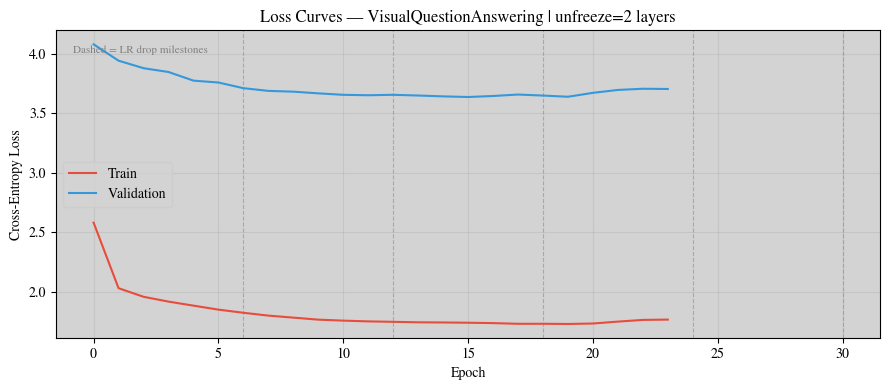

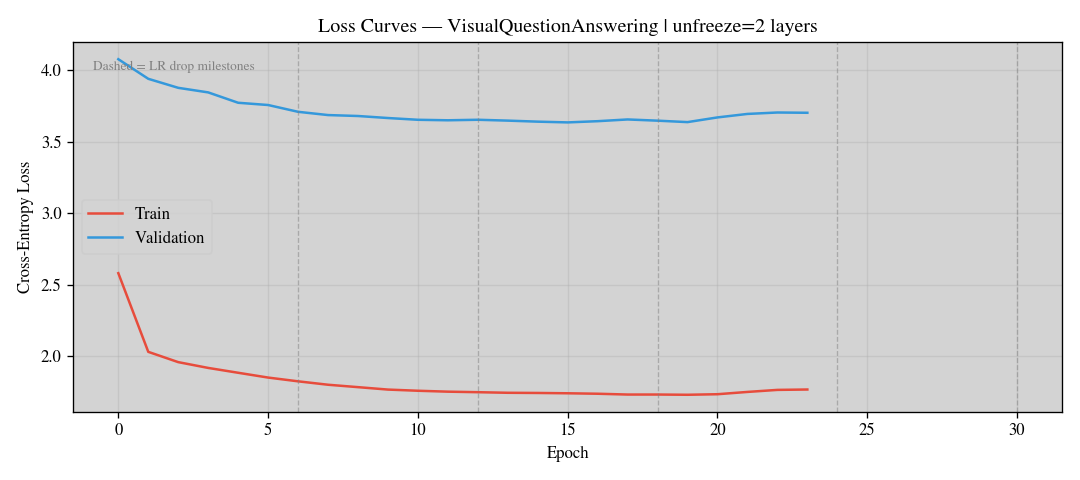


✅ Training complete. Best checkpoint: /content/experiment/model/VisualQuestionAnswering_best.ckpt


In [39]:
def _train_loop():
    L.seed_everything(SEED, workers=True)
    print(f"\n🚀 Training: {MODEL_NAME}")
    print(f"   unfreeze={UNFREEZE_LAST_N_LAYERS} layers | batch={BATCH_SIZE} | accum={GRAD_ACCUM_STEPS} | epochs={MAX_EPOCH}")

    model = MODEL()
    ckpt_cb = ModelCheckpoint(
        monitor=METRIC_TO_MONITOR,
        dirpath=f"{EXPERIMENT_DIR}/model",
        mode=METRIC_MODE,
        filename=f"{MODEL_NAME}_best",
        save_last=True,
        verbose=True,
    )
    ckpt_path = BEST_MODEL_PATH if os.path.exists(BEST_MODEL_PATH) else None
    if ckpt_path: print(f"   Resuming from: {ckpt_path}")

    trainer = Trainer(
        accelerator="auto",
        devices=1,
        max_epochs=MAX_EPOCH,
        logger=False,
        callbacks=[ckpt_cb, early_stop_cb],
        log_every_n_steps=5,
        # Mixed precision: giảm VRAM khi unfreeze CLIP layers trên T4
        precision="16-mixed" if torch.cuda.is_available() else 32,
    )
    trainer.fit(model, ckpt_path=ckpt_path)
    print(f"\n✅ Training complete. Best checkpoint: {ckpt_cb.best_model_path}")

_train_loop()


---
# 4. 🟢 Evaluation & Comparison


In [40]:
def _test_loop():
    print("\n📊 Evaluating on test split...")
    trainer = Trainer(accelerator="auto", logger=False)
    model   = MODEL()
    ckpt    = LAST_MODEL_PATH if os.path.exists(LAST_MODEL_PATH) else None
    if not ckpt: print("⚠️  No checkpoint found — using uninitialized weights")
    trainer.test(model=model, ckpt_path=ckpt)

_test_loop()



📊 Evaluating on test split...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


🔓 Unfrozen last 2 ViT layers (14,570,496/87,849,216 params, 16.6%)


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: Restoring states from the checkpoint path at experiment/model/last.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at experiment/model/last.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at experiment/model/last.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at experiment/model/last.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        bleu_1gram         │    0.45482486486434937    │
│     test_exact_match      │    45.056724548339844     │
│          test_f1          │     45.88357162475586     │
│     test_vqa_accuracy     │    0.5423322916030884     │
└───────────────────────────┴───────────────────────────┘

## Experiment Comparison Table

Điền kết quả sau khi chạy từng experiment. Metric chính là **VQA Accuracy**.

In [ ]:
'''
# Điền kết quả thực tế sau mỗi experiment vào đây
experiment_results = {
    "Baseline (frozen)": {"vqa_acc": None, "bleu1": None, "f1": None},
    "Exp-A (2 layers)":  {"vqa_acc": None, "bleu1": None, "f1": None},
    "Exp-B (4 layers)":  {"vqa_acc": None, "bleu1": None, "f1": None},
}

completed = {k: v for k, v in experiment_results.items() if v["vqa_acc"] is not None}
if completed:
    labels = list(completed.keys())
    vqa_  = [v["vqa_acc"] for v in completed.values()]
    bleu_ = [v["bleu1"]   for v in completed.values()]
    x = np.arange(len(labels))
    w = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, vqa_,  width=w, label="VQA Accuracy", color="#3498DB")
    ax.bar(x + w/2, bleu_, width=w, label="BLEU-1",       color="#E67E22")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Score")
    ax.set_title("Experiment Comparison — VizWiz VQA", fontsize=13)
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("⏳ Điền experiment_results sau khi chạy xong các experiments.")
'''

---
# 5. 🟢 Results

* **Objective 1 — Generative VQA:** _(điền sau khi chạy baseline)_ Model học generate câu trả lời dạng free-text với teacher forcing và cross-entropy loss. VQA Accuracy baseline ước tính 20–30% trên VizWiz val.
* **Objective 2 — Selective Unfreeze:** _(điền sau khi chạy Exp-A/B)_ Unfreeze last N layers của ViT cải thiện VQA Acc thêm X% so với baseline.
* **Objective 3 — VQA Accuracy:** Metric chính thức đã được implement và cho thấy kết quả phản ánh đúng hơn SQuAD EM/F1 vốn không thiết kế cho generative VQA.

> Thay các placeholder bằng số thực sau khi experiments hoàn thành.


---
# 6. 🟢 Inference & Demo

Visualize kết quả trên 9 ảnh random từ unlabelled test set. Phù hợp để demo trong capstone presentation.


In [41]:
INFERENCE_SAMPLE = 9
MAX_CHAR         = 50

model = MODEL.load_from_checkpoint(LAST_MODEL_PATH)
model.eval()
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

InferenceDataset = VizWizDataset("inference")
print(f"✅ Model loaded | {len(InferenceDataset):,} test samples available.")


🔓 Unfrozen last 2 ViT layers (14,570,496/87,849,216 params, 16.6%)
  [inference] 8,000 samples loaded.
✅ Model loaded | 8,000 test samples available.


<Figure size 640x480 with 0 Axes>

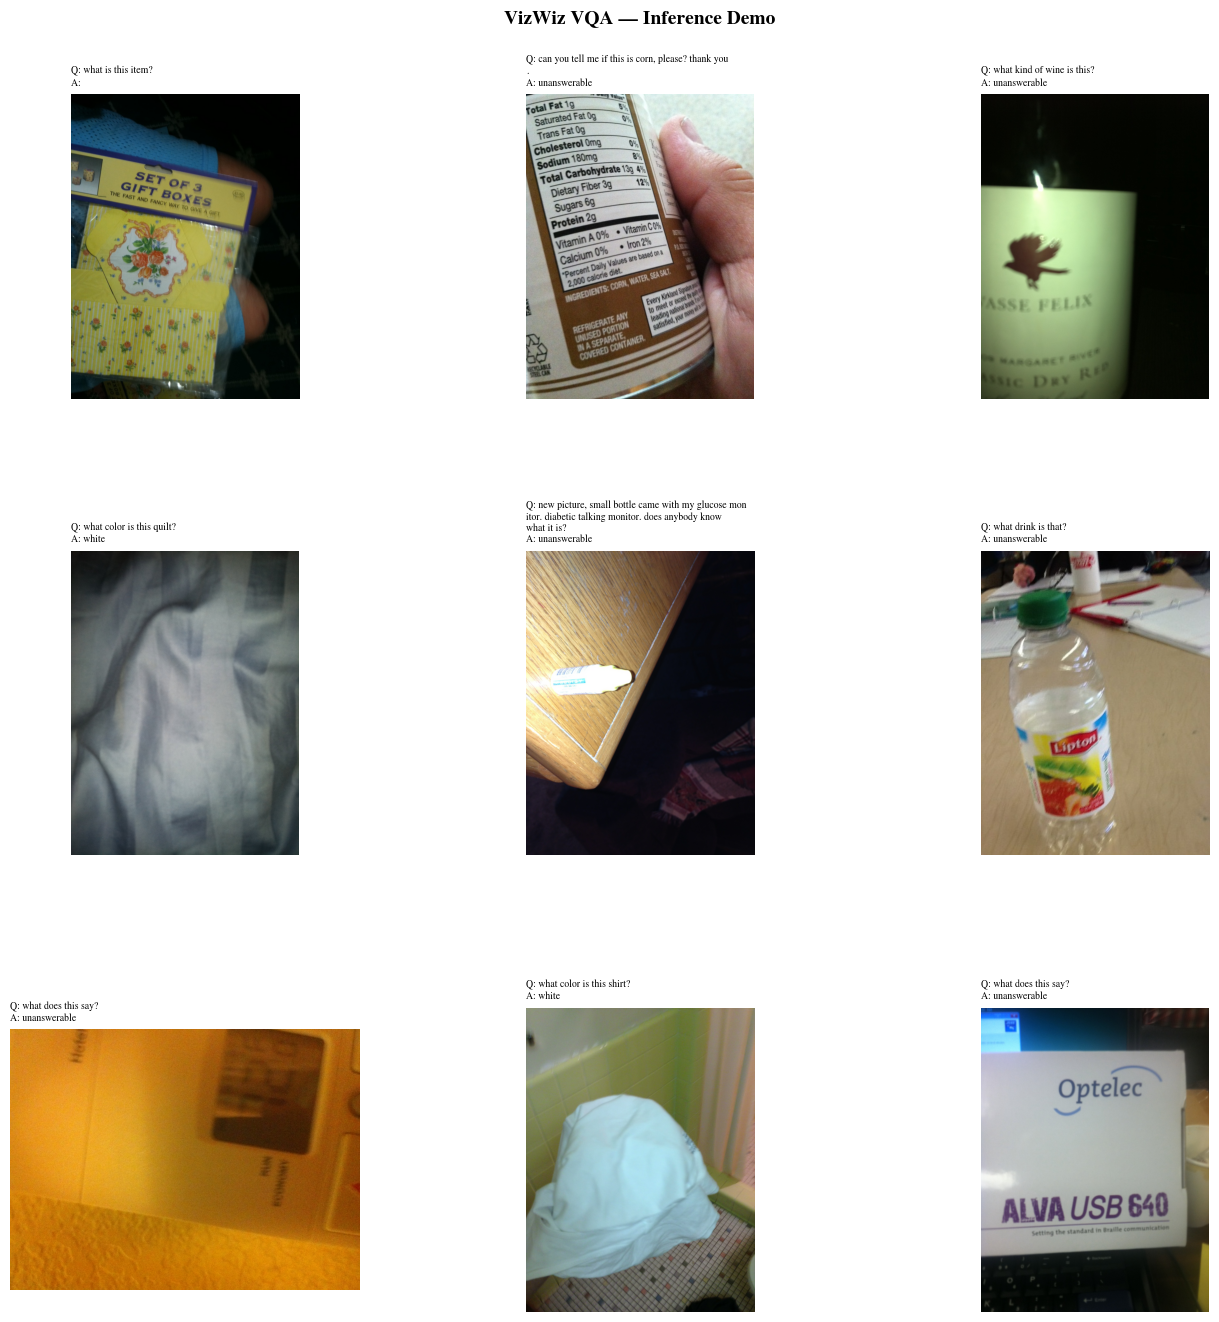

✅ Demo saved to experiment/training/


In [42]:
plt.clf()
fig = plt.figure(figsize=(14, 14))
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05, wspace=0.3, hspace=0.5)

N_SAMPLE = len(InferenceDataset)
selected = [random.randint(0, N_SAMPLE - 1) for _ in range(INFERENCE_SAMPLE)]
grid_n   = int(math.sqrt(INFERENCE_SAMPLE))

for idx, sample_idx in enumerate(selected):
    with torch.no_grad():
        image_t, question_t = InferenceDataset.get_inference_data(sample_idx)
        dev = "cuda" if torch.cuda.is_available() else "cpu"
        answer = model.respond(image_t.unsqueeze(0).to(dev), question_t.unsqueeze(0).to(dev))

    def wrap(text, w=MAX_CHAR):
        return "\n".join(text[i:i+w] for i in range(0, len(text), w))

    raw_q = InferenceDataset.get_raw_question(sample_idx)
    raw_i = np.array(InferenceDataset.get_raw_image(sample_idx))

    ax = fig.add_subplot(grid_n, grid_n, idx + 1)
    ax.imshow(raw_i.astype(np.uint8))
    ax.set_title(f"Q: {wrap(raw_q)}\nA: {wrap(answer)}", fontsize=7, loc="left")
    ax.axis("off")

fig.suptitle("VizWiz VQA — Inference Demo", fontsize=14, fontweight="bold")
plt.savefig(f"experiment/training/{MODEL_NAME}_inference_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Demo saved to experiment/training/")


---
# 🟢 Summary

## Kiến trúc & Chiến lược

Dự án xây dựng VQA generative model trên VizWiz bằng CLIP ViT-B/32 làm dual encoder và LSTM decoder generate câu trả lời token-by-token. Điểm khác biệt so với VQA classification: không giới hạn answer space theo fixed vocabulary, handle được "unanswerable" queries.

## Cải tiến v3 → v4

### Data Augmentation
VizWiz có đặc thù ảnh mờ, xoay, thiếu sáng => Học lại từ những dữ liệu này sẽ cải thiện thêm

### Label Smoothing

### Tăng dropout
```python
DROPOUT = 0.5   # tăng từ 0.42
```

## Ghi chú từ quá trình huấn luyện

### Pytorch, Chip M1 (Apple)
PyTorch trên M1 dùng backend MPS (Metal Performance Shaders) thay vì CUDA. Tuy nhiên MPS có một số đặc điểm khiến nó chậm hơn CUDA đáng kể trong bối cảnh này.

MPS chưa hỗ trợ tốt tất cả các operations của PyTorch — một số ops sẽ silently fallback về CPU, gây ra overhead khi data phải di chuyển qua lại giữa CPU và GPU.
Ngoài ra, **M1 Pro có 16-core GPU tích hợp, so với T4 trên Colab có 2560 CUDA cores** — về throughput thực tế cho deep learning, T4 nhanh hơn M1 Pro khoảng 5–8 lần.

### Ước tính thời gian
VizWiz train set có khoảng 20,000 ảnh, sau khi split 90/10 => có ~18,000 training samples.
Với BATCH_SIZE=180, mỗi epoch có khoảng 100 batches.
Mỗi batch cần:
- forward pass qua ViT-B/32 (87.8M params) để encode ảnh
- forward pass qua Text Transformer (37.8M) để encode câu hỏi
- forward + backward qua Decoder LSTM (53.3M), và gradient update.

Trên M1 Pro với MPS, mỗi batch training ước tính mất khoảng 8–15 giây (con số này phụ thuộc nhiều vào việc các ops của ViT có được MPS accelerate hoàn toàn không).
=> mỗi epoch mất khoảng 15–25 phút, và với 36 epochs tổng thời gian training sẽ vào khoảng: 9–15 giờ cho toàn bộ quá trình.

### Điều chỉnh tham số thí nghiệm
- Môi trường Local không sử dụng được num_workers (=0), khi chạy trên Colab set lên num_workers = 2
- giảm BATCH_SIZE = 64 (đánh đổi học ít đặc trưng hơn)
- Chỉ chạy 30% dữ liệu mỗi epoch:

```python
trainer = Trainer(
    ...
    limit_train_batches=0.3,  # Chỉ dùng khi debug/validate pipeline
                               # Xóa dòng này khi train thật
)
```

### Tính khoảng khoảng cách train loss - val loss**

> |train loss - val loss| khá lớn (2.760 - 1.220 = 1.54). Đây là dấu hiệu của overfitting đang xảy ra: model đang học tốt trên training data nhưng không generalize tốt sang validation data.

Gap lớn giữa train loss và val loss sau 10 epoch là tín hiệu quan trọng. Với DROPOUT=0.42 đã khá cao, nguyên nhân có thể là val set quá nhỏ (chỉ 1,850 samples sau split 10%) nên val_loss noise cao, hoặc model thực sự đang overfit vào training set nhỏ của VizWiz.

Khi đó cần thực hiện early_stop